# TP555 - Lista de Exercícios #3 - Resolução

Este notebook contém as soluções completas para os exercícios propostos na Lista de Exercícios #3 do curso TP555 - AI/ML. Cada seção corresponde a um exercício diferente e inclui explicações, código Python (utilizando bibliotecas como NumPy, Matplotlib, SciKit-Learn, etc.) e plots para ilustrar os resultados.


## Exercício 1: Regressão para Modelos Não-Lineares

Dada a função não-linear:

\[
y = a_0 \, x^{a_1}
\]

com \(a_0 = 1{,}4\), \(a_1 = 3{,}0\) e \(x\) sendo um vetor com \(M = 1000\) amostras retiradas de uma distribuição Uniforme no intervalo \([0, 10)\):

1. **(a)** Plote o gráfico da função não-linear (\(x\) versus \(y\)).
2. **(b)** Linearize a função não-linear.
3. **(c)** Plote o gráfico da função linearizada (\(x\) versus \(y\) linearizado).
4. **(d)** Utilizando a função hipótese que lineariza a função geradora:
   - Plote a superfície de erro (superfície de custo em função dos pesos).
   - Encontre os valores ótimos dos pesos da função hipótese utilizando a Equação Normal.
   - Encontre os pesos da função hipótese utilizando o algoritmo do gradiente descendente em batelada, com critério de parada quando a diferença absoluta entre o erro atual e o anterior for inferior a \(1 \times 10^{-5}\) ou atingir 1000 épocas. Ajuste o passo de aprendizagem \(lpha\) para convergência.
   - Plote a superfície de contorno mostrando o histórico de atualização dos pesos e seus valores ótimos.
   - Plote o gráfico de erro versus número de épocas.
5. **(e)** Quais os valores dos pesos encontrados pelo algoritmo do gradiente descendente em batelada?


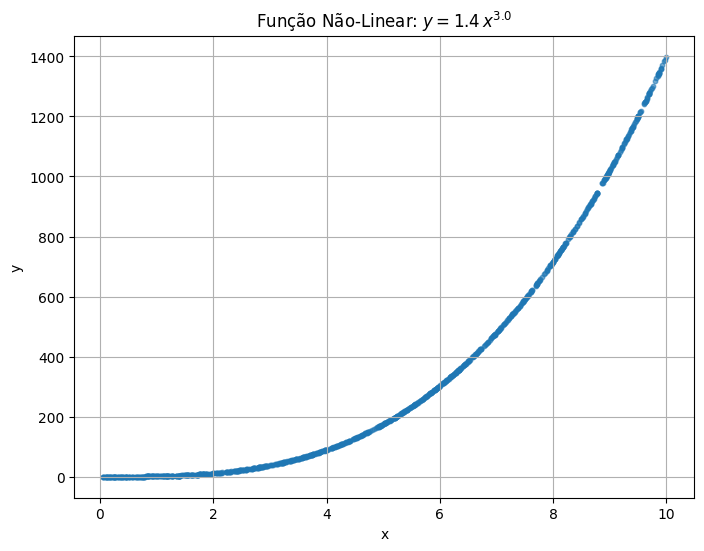

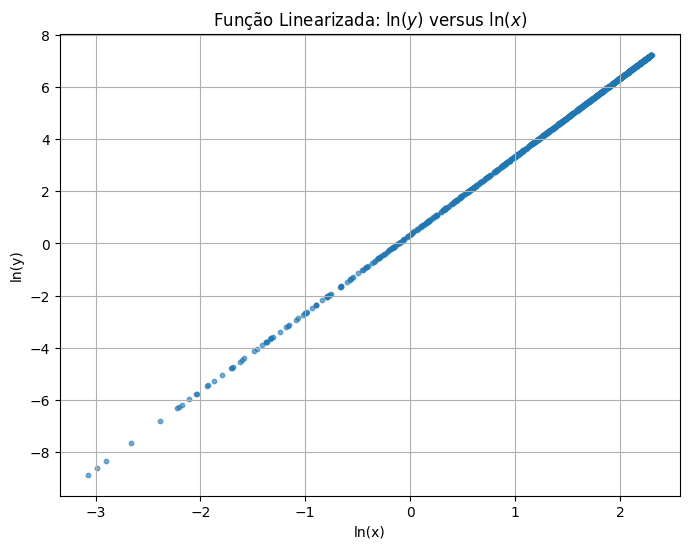

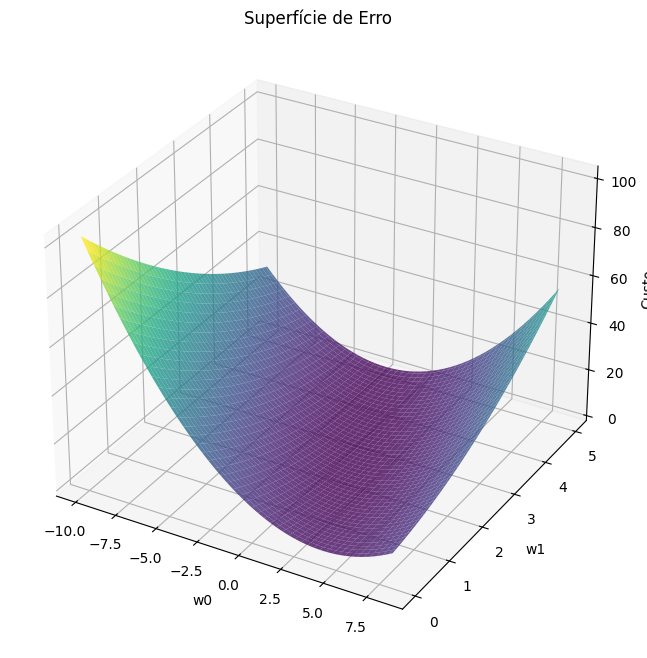

Pesos via Equação Normal: w0 = 0.3365, w1 = 3.0000
Pesos via Gradiente Descendente: w0 = 0.4315, w1 = 2.9470, Épocas: 819


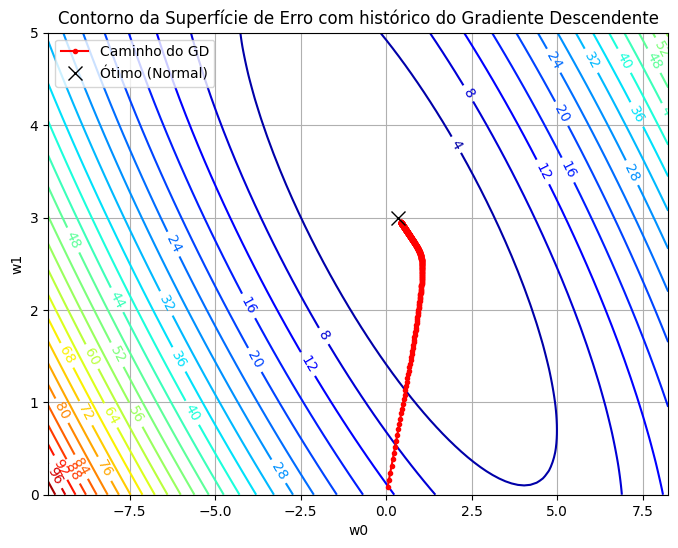

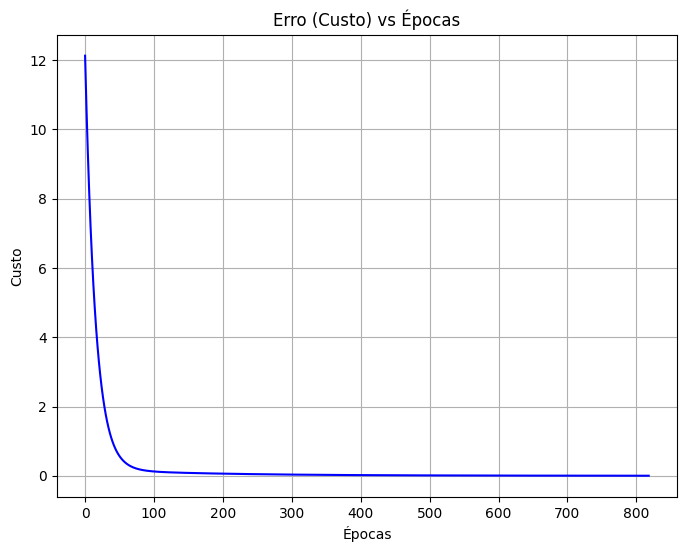

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurações iniciais
np.random.seed(42)
M = 1000
x = np.random.uniform(0, 10, M)
a0_true = 1.4
a1_true = 3.0
y = a0_true * x ** a1_true

# (a) Plotar gráfico da função não-linear
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.6)
plt.title("Função Não-Linear: $y = 1.4 \, x^{3.0}$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# (b) Linearizar a função: y = a0 * x^a1 -> ln(y) = ln(a0) + a1 * ln(x)
# Precisamos remover valores onde x==0 para evitar log(0)
mask = x > 0
x_nonzero = x[mask]
y_nonzero = y[mask]
ln_x = np.log(x_nonzero)
ln_y = np.log(y_nonzero)

# (c) Plotar gráfico da função linearizada
plt.figure(figsize=(8, 6))
plt.scatter(ln_x, ln_y, s=10, alpha=0.6)
plt.title("Função Linearizada: $\ln(y)$ versus $\ln(x)$")
plt.xlabel("ln(x)")
plt.ylabel("ln(y)")
plt.grid(True)
plt.show()

# (d) Hipótese linear: ln(y) = w0 + w1 * ln(x)
# Construir matriz de design para regressão linear
X_lin = np.vstack((np.ones_like(ln_x), ln_x)).T
Y_lin = ln_y.reshape(-1, 1)

# (d.i) Superfície de erro para diferentes pares (w0, w1)
def compute_cost(W, X, Y):
    m = len(Y)
    preds = X.dot(W)
    cost = (1/(2*m)) * np.sum((preds - Y)**2)
    return cost

# Grid de valores para w0 e w1
w0_vals = np.linspace(np.min(ln_y)-1, np.max(ln_y)+1, 100)
w1_vals = np.linspace(0, 5, 100)
W0_grid, W1_grid = np.meshgrid(w0_vals, w1_vals)
cost_grid = np.zeros_like(W0_grid)

for i in range(W0_grid.shape[0]):
    for j in range(W0_grid.shape[1]):
        W_temp = np.array([[W0_grid[i, j]], [W1_grid[i, j]]])
        cost_grid[i, j] = compute_cost(W_temp, X_lin, Y_lin)

# Plotar superfície de custo (representação 3D)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0_grid, W1_grid, cost_grid, cmap='viridis', alpha=0.8)
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('Custo')
ax.set_title("Superfície de Erro")
plt.show()

# (d.ii) Encontrar pesos ótimos via Equação Normal
W_normal = np.linalg.inv(X_lin.T.dot(X_lin)).dot(X_lin.T).dot(Y_lin)
w0_opt_norm, w1_opt_norm = W_normal.flatten()
print(f"Pesos via Equação Normal: w0 = {w0_opt_norm:.4f}, w1 = {w1_opt_norm:.4f}")

# (d.iii) Gradiente Descendente em batelada
alpha = 0.01  # passo de aprendizagem
W_gd = np.zeros((2, 1))
m = len(Y_lin)
J_history = []
W_history = []

for epoch in range(1000):
    preds = X_lin.dot(W_gd)
    gradient = (1/m) * X_lin.T.dot(preds - Y_lin)
    W_gd = W_gd - alpha * gradient
    cost = compute_cost(W_gd, X_lin, Y_lin)
    J_history.append(cost)
    W_history.append(W_gd.flatten())

    # Critério de parada
    if epoch > 0 and abs(J_history[-2] - J_history[-1]) < 1e-5:
        break

w0_opt_gd, w1_opt_gd = W_gd.flatten()
print(f"Pesos via Gradiente Descendente: w0 = {w0_opt_gd:.4f}, w1 = {w1_opt_gd:.4f}, Épocas: {epoch+1}")

# (d.iv) Plotar superfície de contorno com histórico de W e ponto ótimo
plt.figure(figsize=(8, 6))
CS = plt.contour(W0_grid, W1_grid, cost_grid, levels=30, cmap='jet')
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Contorno da Superfície de Erro com histórico do Gradiente Descendente')
W_hist_arr = np.array(W_history)
plt.plot(W_hist_arr[:, 0], W_hist_arr[:, 1], 'ro-', markersize=3, label='Caminho do GD')
plt.plot(w0_opt_norm, w1_opt_norm, 'kx', markersize=10, label='Ótimo (Normal)')
plt.legend()
plt.grid(True)
plt.show()

# (d.v) Plotar erro vs épocas
plt.figure(figsize=(8, 6))
plt.plot(range(len(J_history)), J_history, 'b-')
plt.title('Erro (Custo) vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid(True)
plt.show()


## Exercício 2: Regressão Polinomial e Overfitting

Suponha que você esteja usando regressão polinomial. Você plota as curvas de aprendizado e percebe que há uma grande diferença entre o erro de treinamento e o erro de validação.

- **O que está acontecendo?**
- **Quais são as três maneiras de resolver isso?**

**Resposta esperada:**
- O modelo está com **overfitting** (alta variância), pois se ajusta muito bem aos dados de treinamento, mas não generaliza para o conjunto de validação.
- Três maneiras de resolver:
  1. Reduzir o grau do polinômio (diminuir a complexidade do modelo).
  2. Utilizar regularização (Ridge, Lasso, etc.).
  3. Aumentar a quantidade de dados de treinamento ou usar técnicas como *data augmentation*.


## Exercício 3: Comparação entre Regressões Ridge e LASSO

Dada a seguinte versão ruidosa da função objetivo:

\[
y_{noisy} = 2 + x + 0{,}5 x^2 + n,
\]

onde \(x\) é um vetor coluna com \(M = 100\) elementos retirados de uma distribuição uniforme entre \([-3, 3]\) e \(n\) é ruído Gaussiano \(\mathcal{N}(0, 1)\). Utilizando um polinômio de ordem 90, padronização de atributos e:

1. Regressão LASSO para \(\lambda\) variando entre \(10^{-10}\) e \(1\) (vetor de 1000 valores).
2. Dividir os dados em treino (70%) e validação (30%).

Para cada \(\lambda\):
- Treinar o modelo.
- Calcular erros de treinamento e validação.
- Armazenar erros e encontrar \(\lambda\) ótimo baseado no erro de validação mínimo.

Plotar:
- Função objetivo e sua versão ruidosa.
- Erros de treinamento e validação versus \(\lambda\).
- Função hipótese (modelo treinado) comparada com a função objetivo e a versão ruidosa.
- Valores dos pesos do modelo ótimo.

Repetir todo o processo para Regressão Ridge.

**Objetivos:**
- Comparar comportamento dos erros.
- Observar diferenças nos valores dos pesos entre Lasso e Ridge.


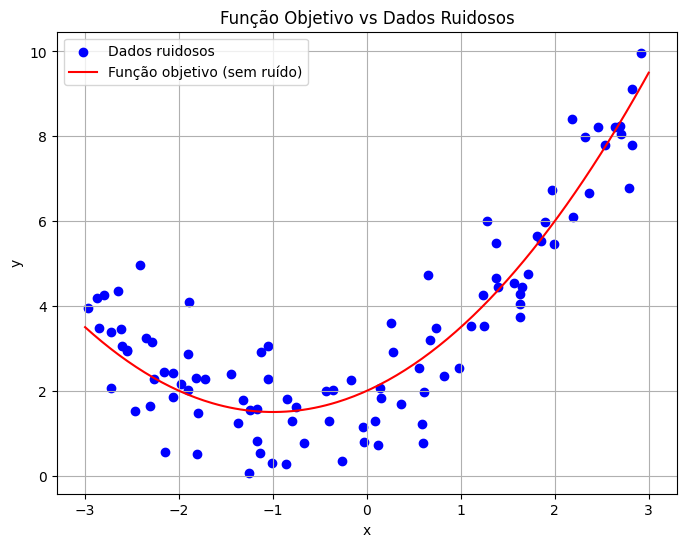

Melhor lambda para Lasso: 0.002002


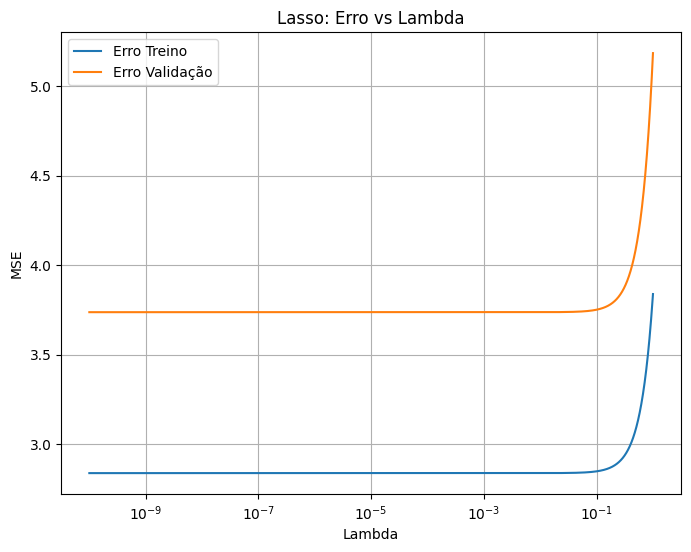

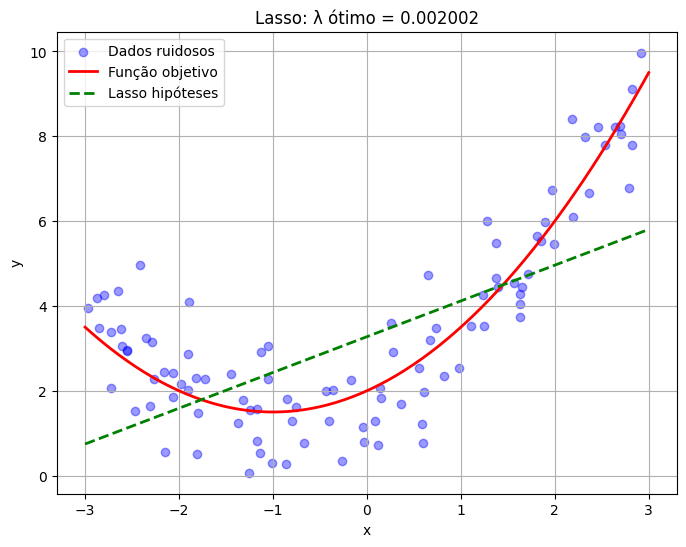

Pesos ótimos Lasso (incluindo intercepto):
[3.12157413 1.4050828 ]
Melhor lambda para Ridge: 0.113113


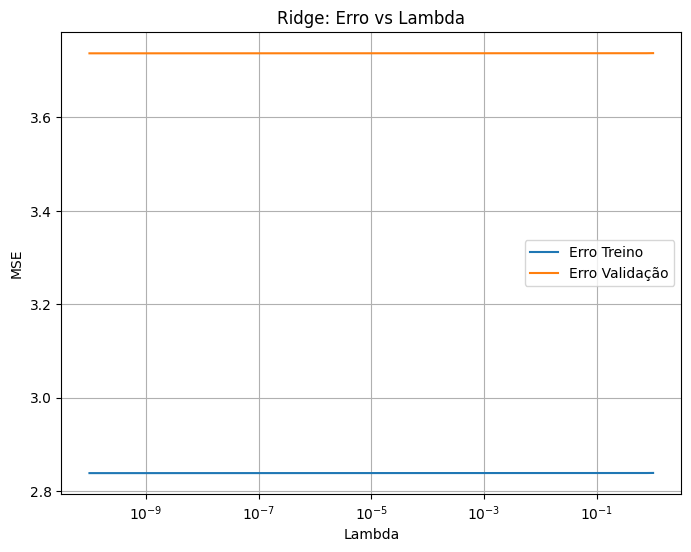

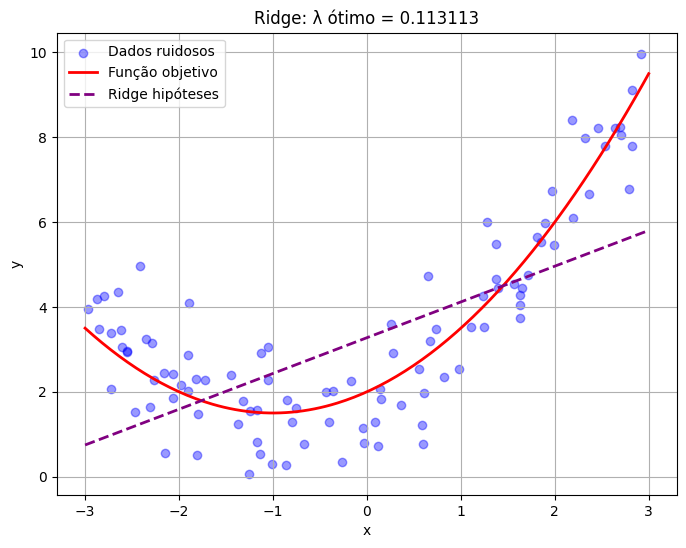

Pesos ótimos Ridge (incluindo intercepto):
[3.12157413 1.40481476]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Gerar dados
M = 100
x = np.random.uniform(-3, 3, M).reshape(-1, 1)
noise = np.random.randn(M, 1)
y_true = 2 + x + 0.5 * x**2
y_noisy = y_true + noise

# a) Plotar função objetivo e versão ruidosa
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, color='blue', label='Dados ruidosos')
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_clean_plot = 2 + x_plot + 0.5 * x_plot**2
plt.plot(x_plot, y_clean_plot, color='red', label='Função objetivo (sem ruído)')
plt.title("Função Objetivo vs Dados Ruidosos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Dividir em treino e validação
x_train, x_val, y_train, y_val = train_test_split(x, y_noisy, test_size=0.3, random_state=42)

# Parâmetros
lambdas = np.linspace(1e-10, 1, 1000)

# Função auxiliar para testar Lasso ou Ridge
def test_regularization(ModelClass, lambdas, x_train, y_train, x_val, y_val):
    train_errors = []
    val_errors = []
    best_val_error = np.inf
    best_lambda = None
    best_model = None

    for lam in lambdas:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', ModelClass(alpha=lam))
        ])
        pipeline.fit(x_train, y_train.ravel())
        y_train_pred = pipeline.predict(x_train)
        y_val_pred = pipeline.predict(x_val)
        train_mse = mean_squared_error(y_train, y_train_pred)
        val_mse = mean_squared_error(y_val, y_val_pred)
        train_errors.append(train_mse)
        val_errors.append(val_mse)

        if val_mse < best_val_error:
            best_val_error = val_mse
            best_lambda = lam
            best_model = pipeline

    return np.array(train_errors), np.array(val_errors), best_lambda, best_model

# c) Testar Lasso
lasso_train_err, lasso_val_err, best_lambda_lasso, best_lasso_model = test_regularization(Lasso, lambdas, x_train, y_train, x_val, y_val)
print(f"Melhor lambda para Lasso: {best_lambda_lasso:.6f}")

# e) Plotar erros vs lambda para Lasso
plt.figure(figsize=(8, 6))
plt.plot(lambdas, lasso_train_err, label='Erro Treino')
plt.plot(lambdas, lasso_val_err, label='Erro Validação')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Lasso: Erro vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# g) Plotar função hipótese ótimo (Lasso) vs objetivo e dados ruidosos
y_lasso_pred = best_lasso_model.predict(x_plot)
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, color='blue', alpha=0.4, label='Dados ruidosos')
plt.plot(x_plot, y_clean_plot, color='red', linewidth=2, label='Função objetivo')
plt.plot(x_plot, y_lasso_pred, color='green', linestyle='--', linewidth=2, label='Lasso hipóteses')
plt.title(f"Lasso: λ ótimo = {best_lambda_lasso:.6f}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# h) Valores dos pesos Lasso ótimos
print("Pesos ótimos Lasso (incluindo intercepto):")
regressor_lasso = best_lasso_model.named_steps['reg']
weights_lasso = np.concatenate(([regressor_lasso.intercept_], regressor_lasso.coef_))
print(weights_lasso)

# i) Repetir para Ridge
ridge_train_err, ridge_val_err, best_lambda_ridge, best_ridge_model = test_regularization(Ridge, lambdas, x_train, y_train, x_val, y_val)
print(f"Melhor lambda para Ridge: {best_lambda_ridge:.6f}")

# j) Plotar erros vs lambda para Ridge
plt.figure(figsize=(8, 6))
plt.plot(lambdas, ridge_train_err, label='Erro Treino')
plt.plot(lambdas, ridge_val_err, label='Erro Validação')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Ridge: Erro vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# Função hipótese ótimo (Ridge) vs objetivo e dados ruidosos
y_ridge_pred = best_ridge_model.predict(x_plot)
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, color='blue', alpha=0.4, label='Dados ruidosos')
plt.plot(x_plot, y_clean_plot, color='red', linewidth=2, label='Função objetivo')
plt.plot(x_plot, y_ridge_pred, color='purple', linestyle='--', linewidth=2, label='Ridge hipóteses')
plt.title(f"Ridge: λ ótimo = {best_lambda_ridge:.6f}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Valores dos pesos Ridge ótimos
print("Pesos ótimos Ridge (incluindo intercepto):")
regressor_ridge = best_ridge_model.named_steps['reg']
weights_ridge = np.concatenate(([regressor_ridge.intercept_], regressor_ridge.coef_))
print(weights_ridge)


## Exercício 4: Early Stopping

Dada a função ruidosa:

\[
y_{noisy} = 2 + x + 0{,}5x^2 + x^3 + n,
\]

onde \(x\) é vetores de \(M=100\) amostras uniformes em \([-3, 3]\) e \(n\) é ruído Gaussiano \(\mathcal{N}(0,1)\), utilizando um polinômio de ordem 30.

1. **(a)** Plote função objetivo e versão ruidosa.
2. **(b)** Encontre manualmente o melhor passo de aprendizagem \(lpha\).
3. **(c)** Execute treinamento por 1000 épocas, armazenando erros de treinamento e validação.
4. **(d)** Para cada época, armazene o modelo com o menor erro de validação.
5. **(e)** Plote erro vs épocas.
6. **(f)** Utilizando o melhor modelo, plote função hipótese vs objetivo e versão ruidosa.


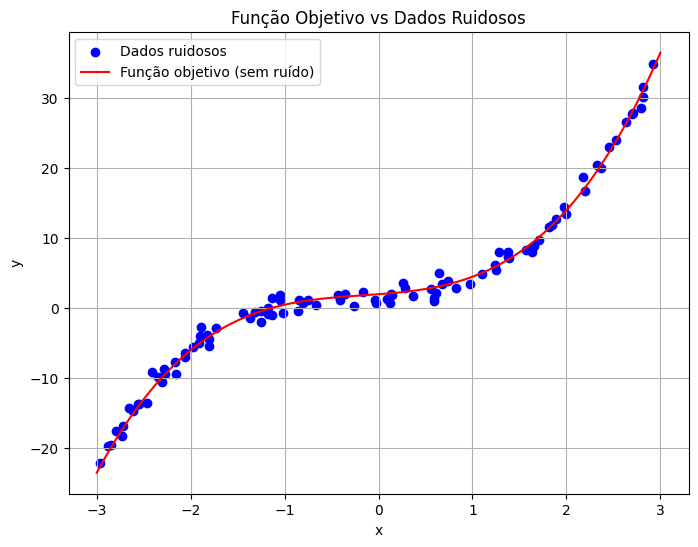

Melhor learning rate: 0.05


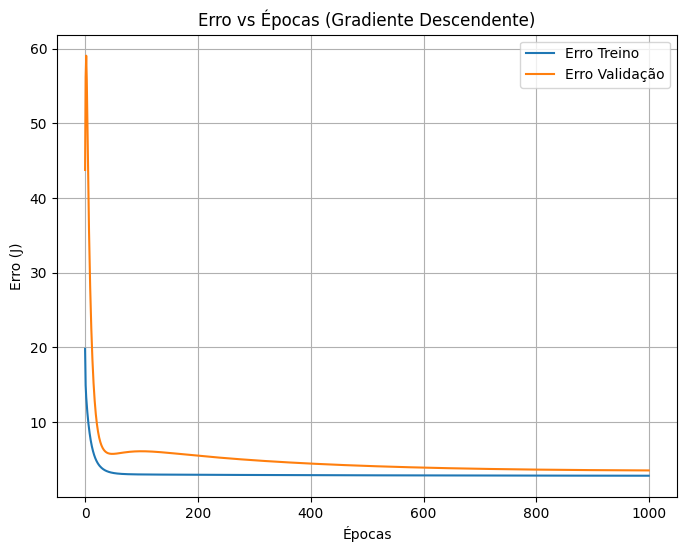

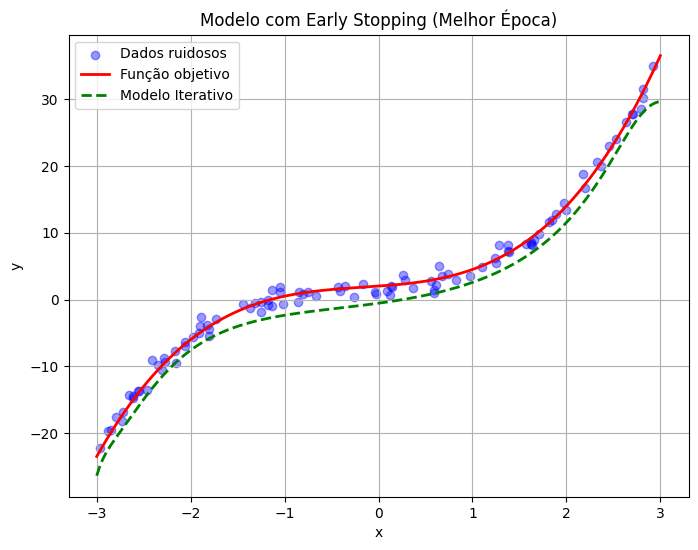

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Gerar dados
M = 100
x = np.random.uniform(-3, 3, M).reshape(-1, 1)
noise = np.random.randn(M, 1)
y_true = 2 + x + 0.5 * x**2 + x**3
y_noisy = y_true + noise

# a) Plotar função objetivo e versão ruidosa
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, color='blue', label='Dados ruidosos')
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_clean_plot = 2 + x_plot + 0.5 * x_plot**2 + x_plot**3
plt.plot(x_plot, y_clean_plot, color='red', label='Função objetivo (sem ruído)')
plt.title("Função Objetivo vs Dados Ruidosos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Dividir em treino e validação
x_train, x_val, y_train, y_val = train_test_split(x, y_noisy, test_size=0.3, random_state=42)

# Construir features polinomiais de ordem 30
def build_poly_features(x, degree):
    return np.hstack([x**i for i in range(degree+1)])

degree = 30
X_train_poly = build_poly_features(x_train, degree)
X_val_poly = build_poly_features(x_val, degree)
X_plot_poly = build_poly_features(x_plot, degree)

# Padronizar atributos (baseado em treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)
X_plot_scaled = scaler.transform(X_plot_poly)

# b) Encontrar manualmente melhor learning rate
learning_rates = [0.001, 0.005, 0.01, 0.05]
best_lr = None
best_val_error = float('inf')

for lr in learning_rates:
    # Inicializar pesos
    W = np.zeros((degree+1, 1))
    m = len(y_train)
    # Treinar por 200 épocas para avaliar
    for epoch in range(200):
        preds = X_train_scaled.dot(W)
        gradient = (1/m) * X_train_scaled.T.dot(preds - y_train)
        W = W - lr * gradient
    # Calcular erro de validação
    val_pred = X_val_scaled.dot(W)
    val_error = np.mean((val_pred - y_val)**2) / 2
    if val_error < best_val_error:
        best_val_error = val_error
        best_lr = lr

print(f"Melhor learning rate: {best_lr}")

# c) Treinar por 1000 épocas, armazenando erros
W = np.zeros((degree+1, 1))
m = len(y_train)
J_train_history = []
J_val_history = []
best_val_error = float('inf')
best_W = None

for epoch in range(1000):
    preds = X_train_scaled.dot(W)
    gradient = (1/m) * X_train_scaled.T.dot(preds - y_train)
    W = W - best_lr * gradient

    # Erros
    train_error = np.mean((X_train_scaled.dot(W) - y_train)**2) / 2
    val_error = np.mean((X_val_scaled.dot(W) - y_val)**2) / 2
    J_train_history.append(train_error)
    J_val_history.append(val_error)

    # Armazenar melhor modelo
    if val_error < best_val_error:
        best_val_error = val_error
        best_W = W.copy()

# e) Plotar erro vs épocas
plt.figure(figsize=(8, 6))
plt.plot(range(1000), J_train_history, label='Erro Treino')
plt.plot(range(1000), J_val_history, label='Erro Validação')
plt.xlabel('Épocas')
plt.ylabel('Erro (J)')
plt.title('Erro vs Épocas (Gradiente Descendente)')
plt.legend()
plt.grid(True)
plt.show()

# f) Plotar função hipótese do melhor modelo vs objetivo e ruidosa
y_best_plot = X_plot_scaled.dot(best_W)
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noisy, color='blue', alpha=0.4, label='Dados ruidosos')
plt.plot(x_plot, y_clean_plot, color='red', linewidth=2, label='Função objetivo')
plt.plot(x_plot, y_best_plot, color='green', linestyle='--', linewidth=2, label='Modelo Iterativo')
plt.title('Modelo com Early Stopping (Melhor Época)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## Exercício 5: Validação Cruzada com Dados de COVID-19

Utilizando o arquivo `covid19.csv`, onde a primeira coluna é o número de dias desde o primeiro caso de COVID-19 e a segunda coluna é o número de casos ativos:

1. **(a)** Plote os valores do arquivo (dias vs casos ativos).
2. **(b)** Encontre uma aproximação polinomial que represente bem os dados usando:
   - Validação Holdout (80% treino / 20% val)
   - Validação Cruzada k-fold (k = 10)
   - Validação Leave-p-out (p = 1)
   - Curvas de aprendizado
   Testar polinômios de ordem 1 a 12.
3. **(c)** De posse da melhor ordem de polinômio, treine o modelo com todos os dados (usar StandardScaler).
4. **(d)** Criar vetor de x de 1 a 70 e fazer predição de casos ativos.
5. **(e)** Sabendo que o total de leitos de UTI no Brasil é 40600, prever em quantos dias desde 26-02-2020 esse total seria atingido.


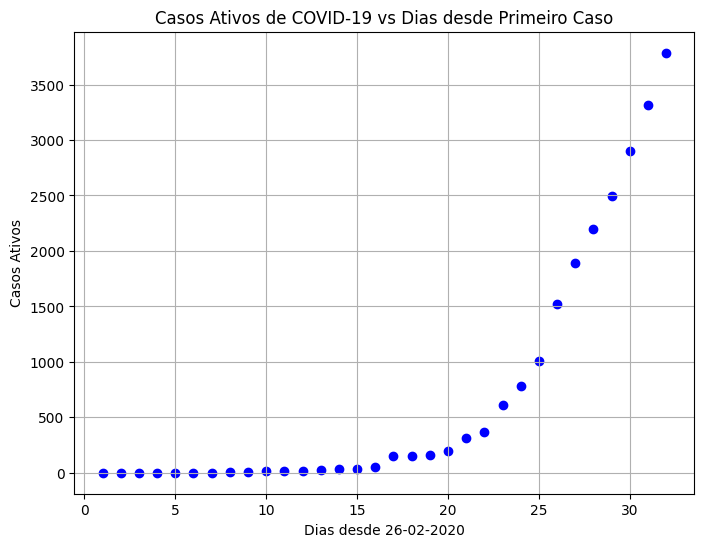

    degree        holdout          kfold    leave_p_out
0        1  607938.650895  466942.662464  488196.919474
1        2   65733.269026   79044.541344   76072.911843
2        3    4174.599618    7922.639707    8190.493408
3        4    4146.266689    9584.548243    9656.393530
4        5    6165.749154    5480.048330    5105.069525
5        6    6130.288942    6218.020851    5990.643314
6        7    5157.649334    7713.296646    7583.073002
7        8    5018.029408    3615.990439    4029.069230
8        9   16382.470414    7702.218127    7080.792742
9       10   27579.994534   18472.674855   17252.127738
10      11   16390.101465   11687.336201   12128.600838
11      12    8265.015709    5032.768566    3972.910327
Grau ótimo segundo K-Fold: 8


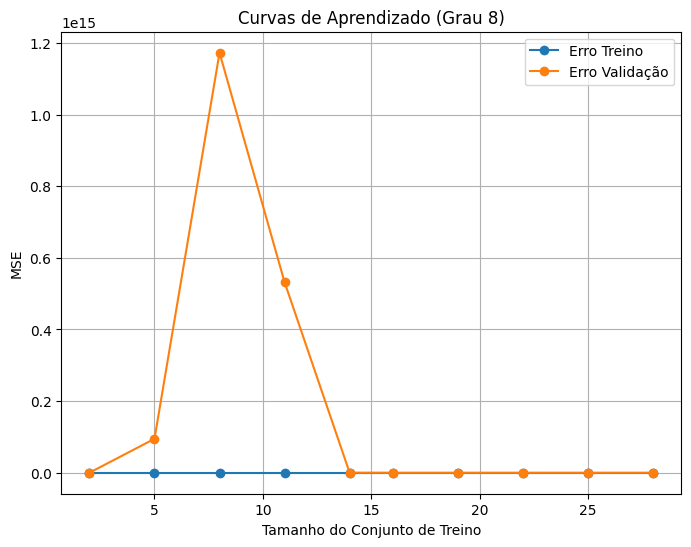

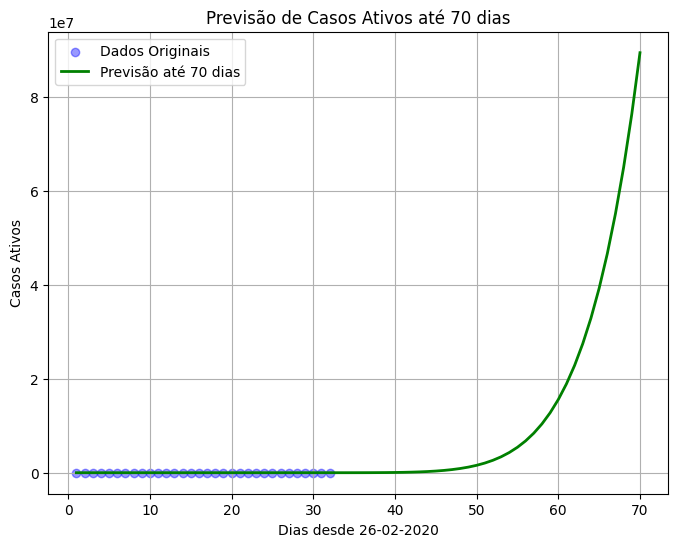

Número estimado de dias para atingir 40600 casos ativos: 40 dias desde 26-02-2020


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error

# a) Carregar dados
df = pd.read_csv('covid19.csv', header=None)
x = df[0].to_numpy().reshape(-1, 1)
y = df[1].to_numpy().reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue')
plt.title('Casos Ativos de COVID-19 vs Dias desde Primeiro Caso')
plt.xlabel('Dias desde 26-02-2020')
plt.ylabel('Casos Ativos')
plt.grid(True)
plt.show()

# b) Encontrar melhor ordem de polinômio usando diferentes validações
def evaluate_polynomial_degree(x_data, y_data, degree, cv_method):
    """Retorna MSE médio para dado grau e método de validação."""
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x_data)
    model = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])

    if cv_method == 'holdout':
        xt, xv, yt, yv = train_test_split(X_poly, y_data, test_size=0.2, random_state=42)
        model.fit(xt, yt.ravel())
        pred = model.predict(xv)
        return mean_squared_error(yv, pred)
    elif cv_method == 'kfold':
        kf = KFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_poly, y_data.ravel(), scoring='neg_mean_squared_error', cv=kf)
        return -scores.mean()
    elif cv_method == 'leave_p_out':
        from sklearn.model_selection import LeaveOneOut
        loo = LeaveOneOut()
        scores = cross_val_score(model, X_poly, y_data.ravel(), scoring='neg_mean_squared_error', cv=loo)
        return -scores.mean()

degrees = range(1, 13)
results = {'degree': [], 'holdout': [], 'kfold': [], 'leave_p_out': []}

for deg in degrees:
    results['degree'].append(deg)
    results['holdout'].append(evaluate_polynomial_degree(x, y, deg, 'holdout'))
    results['kfold'].append(evaluate_polynomial_degree(x, y, deg, 'kfold'))
    results['leave_p_out'].append(evaluate_polynomial_degree(x, y, deg, 'leave_p_out'))

results_df = pd.DataFrame(results)
print(results_df)

# Curvas de aprendizado para o grau que apresentar melhor desempenho no K-Fold
best_degree = int(results_df.loc[results_df['kfold'].idxmin()]['degree'])
print(f"Grau ótimo segundo K-Fold: {best_degree}")

# Plotar curvas de aprendizado para o grau ótimo
poly_best = PolynomialFeatures(best_degree)
X_poly_best = poly_best.fit_transform(x)
model_best = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])

train_sizes, train_scores, val_scores = learning_curve(model_best, X_poly_best, y.ravel(), cv=10, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_errors, 'o-', label='Erro Treino')
plt.plot(train_sizes, val_errors, 'o-', label='Erro Validação')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('MSE')
plt.title(f'Curvas de Aprendizado (Grau {best_degree})')
plt.legend()
plt.grid(True)
plt.show()

# c) Treinar modelo com todos os dados usando grau ótimo
X_poly_full = poly_best.fit_transform(x)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_poly_full)
model_final = LinearRegression()
model_final.fit(X_scaled_full, y)

# d) Criar vetor de x de 1 a 70 e predizer
x_future = np.arange(1, 71).reshape(-1, 1)
X_future_poly = poly_best.transform(x_future)
X_future_scaled = scaler_full.transform(X_future_poly)
y_future_pred = model_final.predict(X_future_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.4, label='Dados Originais')
plt.plot(x_future, y_future_pred, color='green', linewidth=2, label='Previsão até 70 dias')
plt.title('Previsão de Casos Ativos até 70 dias')
plt.xlabel('Dias desde 26-02-2020')
plt.ylabel('Casos Ativos')
plt.legend()
plt.grid(True)
plt.show()

# e) Prever quando atingirá 40600 casos ativos
days_to_icu = np.argmax(y_future_pred >= 40600) + 1  # +1 pois índice 0 = dia 1
print(f"Número estimado de dias para atingir 40600 casos ativos: {days_to_icu} dias desde 26-02-2020")


## Exercício 6: Aproximação Polinomial com `reg_poli.csv`

Usando o arquivo `reg_poli.csv`, onde a primeira coluna é \(x\) e a segunda coluna é \(y\) (versão ruidosa de uma função geradora):

1. **(a)** Apresente o gráfico de \(x\) versus \(y\).
2. **(b)** Encontre a melhor aproximação polinomial utilizando holdout (70/30), k-fold (k = 10), leave-p-out (p = 1) e curvas de aprendizado, testando graus de 1 a 12.
3. **(c)** Treine o modelo com todos os dados usando o grau ótimo (usando StandardScaler).
4. **(d)** Plote os pontos ruidosos e as predições do modelo final.


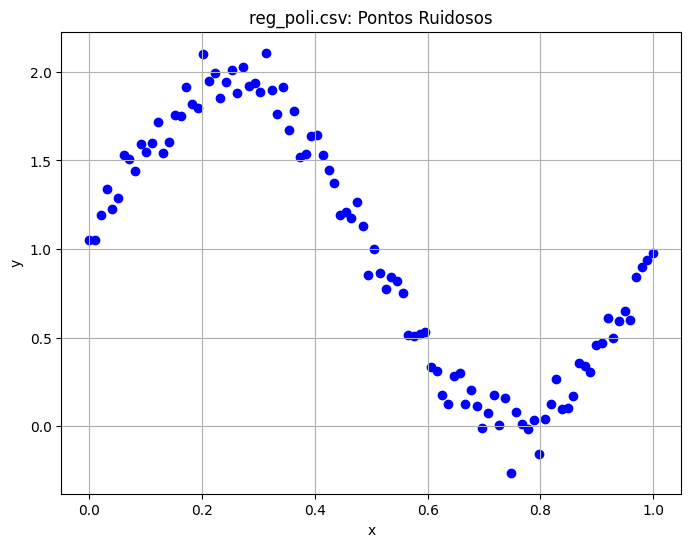

ValueError: Input X contains NaN.
PolynomialFeatures does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error

# a) Carregar dados
df = pd.read_csv('reg_poli.csv', header=None)
x = df[0].to_numpy().reshape(-1, 1)
y = df[1].to_numpy().reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue')
plt.title('reg_poli.csv: Pontos Ruidosos')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

# b) Avaliar melhores graus 1 a 12
def evaluate_degree(x_data, y_data, degree, cv_method):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x_data)
    model = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])

    if cv_method == 'holdout':
        xt, xv, yt, yv = train_test_split(X_poly, y_data, test_size=0.3, random_state=42)
        model.fit(xt, yt.ravel())
        pred = model.predict(xv)
        return mean_squared_error(yv, pred)
    elif cv_method == 'kfold':
        kf = KFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_poly, y_data.ravel(), scoring='neg_mean_squared_error', cv=kf)
        return -scores.mean()
    elif cv_method == 'leave_p_out':
        from sklearn.model_selection import LeaveOneOut
        loo = LeaveOneOut()
        scores = cross_val_score(model, X_poly, y_data.ravel(), scoring='neg_mean_squared_error', cv=loo)
        return -scores.mean()

degrees = range(1, 13)
results6 = {'degree': [], 'holdout': [], 'kfold': [], 'leave_p_out': []}

for deg in degrees:
    results6['degree'].append(deg)
    results6['holdout'].append(evaluate_degree(x, y, deg, 'holdout'))
    results6['kfold'].append(evaluate_degree(x, y, deg, 'kfold'))
    results6['leave_p_out'].append(evaluate_degree(x, y, deg, 'leave_p_out'))

results6_df = pd.DataFrame(results6)
print(results6_df)

best_degree6 = int(results6_df.loc[results6_df['kfold'].idxmin()]['degree'])
print(f"Grau ótimo (k-fold) para reg_poli.csv: {best_degree6}")

# Curvas de aprendizado
poly6_best = PolynomialFeatures(best_degree6)
X_poly6_best = poly6_best.fit_transform(x)
model6_best = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])

train_sizes6, train_scores6, val_scores6 = learning_curve(model6_best, X_poly6_best, y.ravel(), cv=10, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
train_err6 = -train_scores6.mean(axis=1)
val_err6 = -val_scores6.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes6, train_err6, 'o-', label='Erro Treino')
plt.plot(train_sizes6, val_err6, 'o-', label='Erro Validação')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('MSE')
plt.title(f'Curvas de Aprendizado (Grau {best_degree6})')
plt.legend()
plt.grid(True)
plt.show()

# c) Treinar modelo final com todos os dados
X_poly6_full = poly6_best.fit_transform(x)
scaler6_full = StandardScaler()
X6_scaled_full = scaler6_full.fit_transform(X_poly6_full)
model6_final = LinearRegression()
model6_final.fit(X6_scaled_full, y)

# d) Plotar pontos ruidosos e predições
y6_pred = model6_final.predict(X6_scaled_full)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.4, label='Pontos ruidosos')
plt.plot(x, y6_pred, color='green', linewidth=2, label='Aproximação polinomial')
plt.title('Reg_poli.csv: Dados vs Modelo Final')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## Exercício 7: Regressão LASSO com `training_lasso.csv` e `validation_lasso.csv`

1. **(a)** Plote as amostras de ambos os arquivos.
2. **(b)** Utilize polinômio de ordem 40.
3. **(c)** Treine Regressão Linear (sem regularização) com dados de treinamento (aplicar padronização).
4. **(d)** Predição em treino e validação e plot; observar fenômeno (overfitting?).
5. **(e)** Treine modelos LASSO variando \(\lambda\) de \(10^{-10}\) a \(100\); armazene MSE.
6. **(f)** Plotar MSE vs \(\lambda\).
7. **(g)** Encontrar \(\lambda\) ótimo, treinar novo modelo, plotar predições; observar se fenômeno persiste.
8. **(h)** Com o modelo ótimo, variar número de pesos de 2 a 41; armazenar MSE de validação.
9. **(i)** Plotar MSE vs número de pesos.
10. **(j)** Encontrar número de pesos ótimo, treinar modelo considerando apenas estes pesos, plotar predições e comparar.


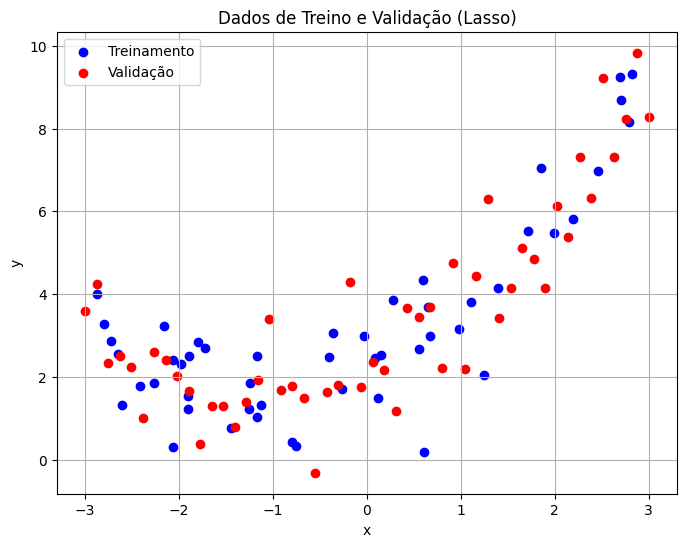

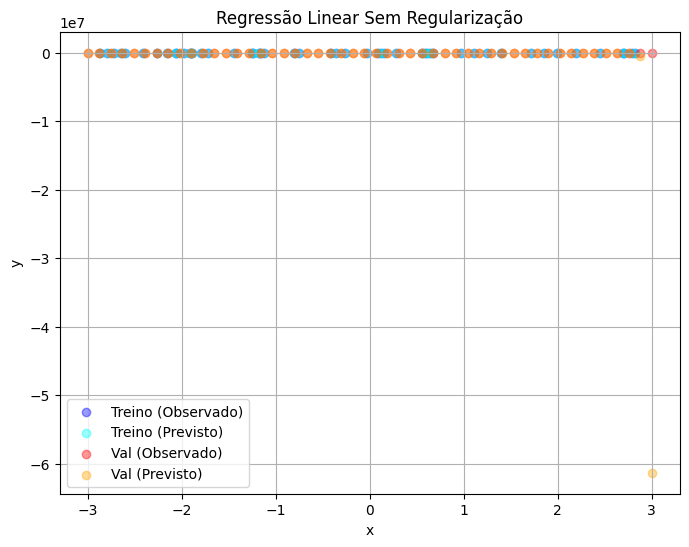

Melhor lambda Lasso: 0.200401


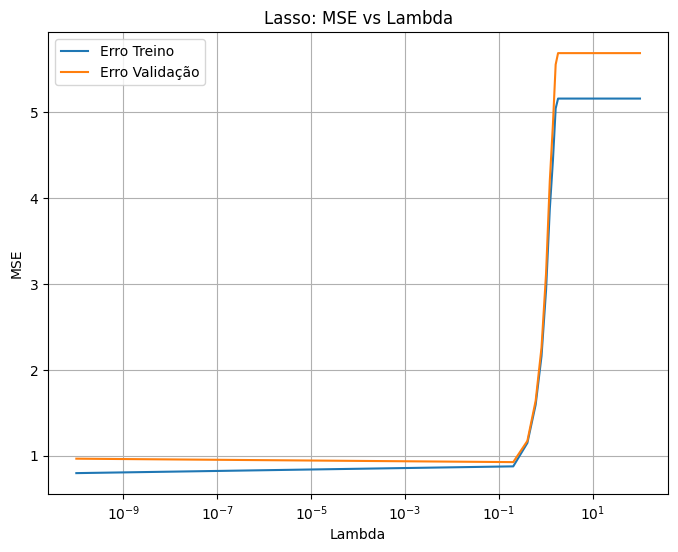

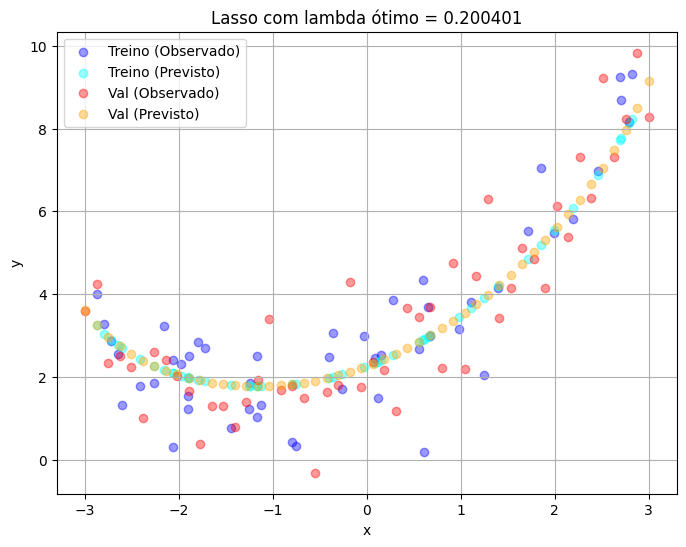

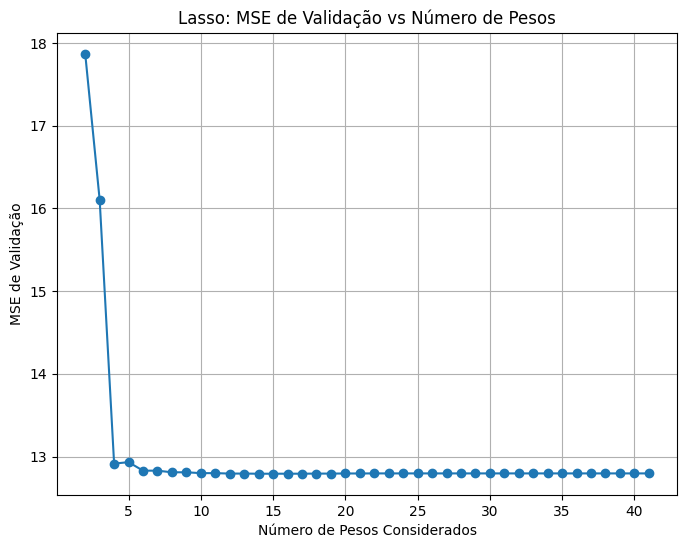

Número ótimo de pesos: 14


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

# Carregar dados
train_df = pd.read_csv('training_lasso.csv', header=None)
val_df = pd.read_csv('validation_lasso.csv', header=None)
x_train = train_df[0].to_numpy().reshape(-1, 1)
y_train = train_df[1].to_numpy().reshape(-1, 1)
x_val = val_df[0].to_numpy().reshape(-1, 1)
y_val = val_df[1].to_numpy().reshape(-1, 1)

# a) Plotar amostras
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Treinamento')
plt.scatter(x_val, y_val, color='red', label='Validação')
plt.title('Dados de Treino e Validação (Lasso)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# b) Construir features polinomiais de ordem 40
degree = 40
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(x_train)
X_val_poly = poly.transform(x_val)

# Padronizar usando parâmetros do treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

# c) Regressão Linear sem regularização
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_train_pred_lin = linreg.predict(X_train_scaled)
y_val_pred_lin = linreg.predict(X_val_scaled)

# d) Plot predições vs reais
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.4, label='Treino (Observado)')
plt.scatter(x_train, y_train_pred_lin, color='cyan', alpha=0.4, label='Treino (Previsto)')
plt.scatter(x_val, y_val, color='red', alpha=0.4, label='Val (Observado)')
plt.scatter(x_val, y_val_pred_lin, color='orange', alpha=0.4, label='Val (Previsto)')
plt.title('Regressão Linear Sem Regularização')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# e) Testar diferentes lambdas para Lasso
lambdas_lasso = np.linspace(1e-10, 100, 500)
train_mse_lasso = []
val_mse_lasso = []
best_val_error = float('inf')
best_lambda_lasso = None
best_lasso_model = None

for lam in lambdas_lasso:
    lasso = Lasso(alpha=lam, tol=1, max_iter=10000)
    lasso.fit(X_train_scaled, y_train.ravel())
    y_train_pred = lasso.predict(X_train_scaled)
    y_val_pred = lasso.predict(X_val_scaled)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)
    train_mse_lasso.append(mse_train)
    val_mse_lasso.append(mse_val)
    if mse_val < best_val_error:
        best_val_error = mse_val
        best_lambda_lasso = lam
        best_lasso_model = lasso

print(f"Melhor lambda Lasso: {best_lambda_lasso:.6f}")

# f) Plotar MSE vs lambda
plt.figure(figsize=(8, 6))
plt.plot(lambdas_lasso, train_mse_lasso, label='Erro Treino')
plt.plot(lambdas_lasso, val_mse_lasso, label='Erro Validação')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Lasso: MSE vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# g) Plot predições com lambda ótimo
y_train_pred_best = best_lasso_model.predict(X_train_scaled)
y_val_pred_best = best_lasso_model.predict(X_val_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.4, label='Treino (Observado)')
plt.scatter(x_train, y_train_pred_best, color='cyan', alpha=0.4, label='Treino (Previsto)')
plt.scatter(x_val, y_val, color='red', alpha=0.4, label='Val (Observado)')
plt.scatter(x_val, y_val_pred_best, color='orange', alpha=0.4, label='Val (Previsto)')
plt.title(f'Lasso com lambda ótimo = {best_lambda_lasso:.6f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# h) Variar número de pesos considerados (2 a 41)
num_weights = range(2, 42)
val_mse_by_num_weights = []

for nw in num_weights:
    # Criar sub-vetor de pesos (considerar apenas primeiros nw coeficientes)
    intercept = best_lasso_model.intercept_
    coefs = best_lasso_model.coef_[:nw-1]
    X_val_subset = X_val_scaled[:, :nw]
    y_val_pred_subset = X_val_subset.dot(np.concatenate(([intercept], coefs)))  # intercept + coefs
    val_mse = mean_squared_error(y_val, y_val_pred_subset)
    val_mse_by_num_weights.append(val_mse)

# i) Plotar MSE vs número de pesos
plt.figure(figsize=(8, 6))
plt.plot(num_weights, val_mse_by_num_weights, 'o-')
plt.xlabel('Número de Pesos Considerados')
plt.ylabel('MSE de Validação')
plt.title('Lasso: MSE de Validação vs Número de Pesos')
plt.grid(True)
plt.show()

# j) Encontrar número de pesos ótimo
best_num_weights = num_weights[np.argmin(val_mse_by_num_weights)]
print(f"Número ótimo de pesos: {best_num_weights}")


## Exercício 8: Early Stopping (Função Simples)

Utilizando a função geradora:

\[
y = 1.0 + 2.0 x + w,
\]

onde \(x\) é um vetor de \(M = 50\) amostras uniformemente distribuídas entre \([-1, 1)\) e \(w\) é ruído Gaussiano com média 0 e variância 0.09. Gerar um conjunto de validação de \(M_{test} = 50\) valores espaçados linearmente em \([-1, 1)\).

1. **(a)** Plotar dados de treino e validação.
2. **(b)** Treinar modelo polinomial de ordem 40 com solução fechada.
3. **(c)** Plotar predições do modelo fechado vs dados.
4. **(d)** Comentar sobre o que está ocorrendo (overfitting).
5. **(e)** Treinar modelo polinomial de ordem 40 usando Gradiente Descendente em lote por 100000 épocas, armazenando os pesos com menor erro de validação (usar melhor learning rate).
6. **(f)** Plotar erro vs épocas.
7. **(g)** Comentar sobre comportamento durante o treinamento.
8. **(h)** Plotar predições do melhor modelo iterativo vs dados.
9. **(i)** Comentar diferença entre este e o modelo fechado.
10. **(j)** Plotar predições usando pesos do final (época 100000) vs dados.
11. **(k)** Comentar.


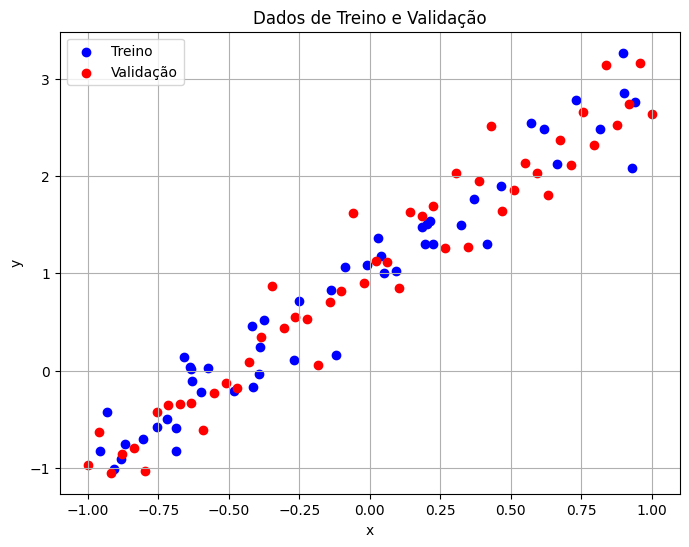

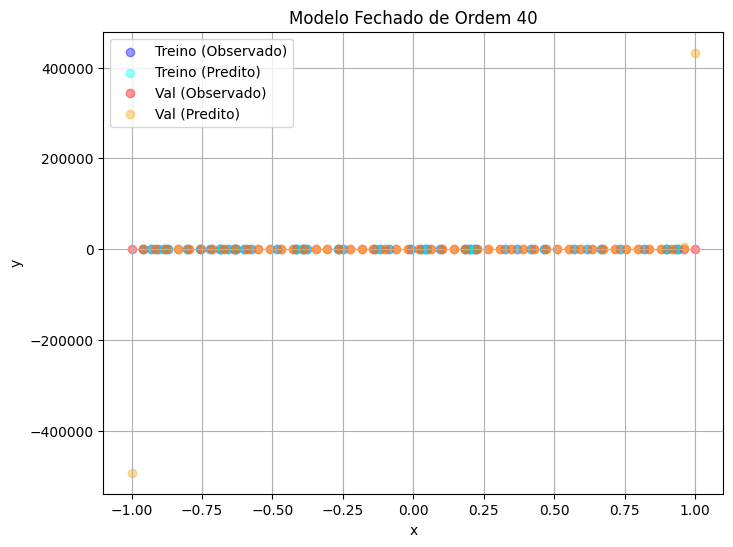

Melhor learning rate para iterativo: 0.005


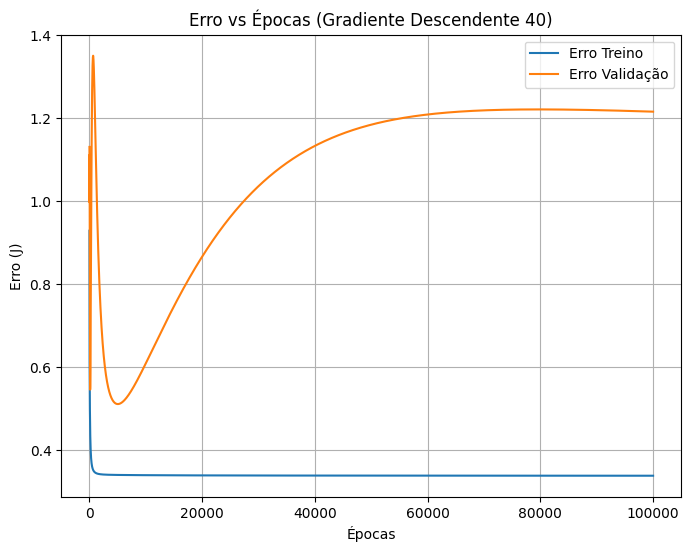

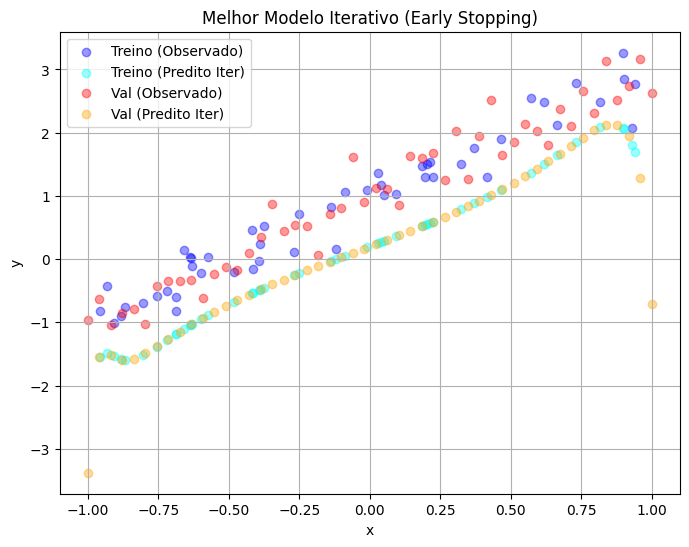

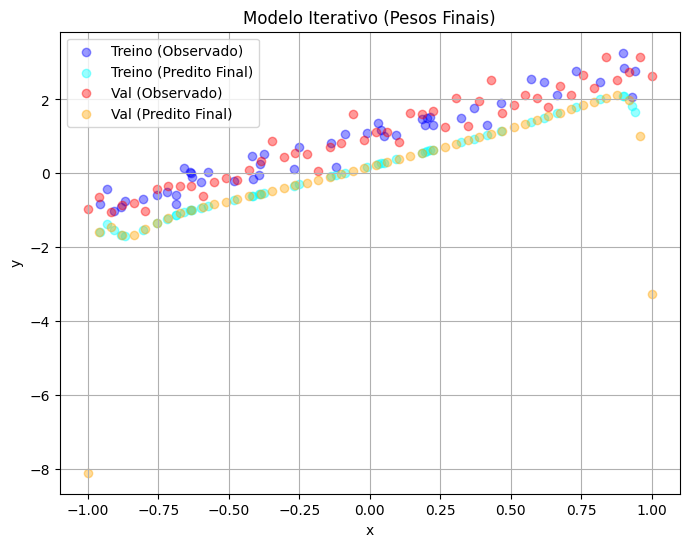

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Gerar dados
M = 50
x_train = np.random.uniform(-1, 1, M).reshape(-1, 1)
w_train = np.random.normal(0, np.sqrt(0.09), (M, 1))
y_train = 1.0 + 2.0 * x_train + w_train

# Conjunto de validação
x_val = np.linspace(-1, 1, 50).reshape(-1, 1)
w_val = np.random.normal(0, np.sqrt(0.09), (50, 1))
y_val = 1.0 + 2.0 * x_val + w_val

# a) Plotar dados
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Treino')
plt.scatter(x_val, y_val, color='red', label='Validação')
plt.title('Dados de Treino e Validação')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# b) Modelo polinomial de ordem 40 (fechado)
degree = 40
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(x_train)
X_val_poly = poly.transform(x_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

linreg_closed = LinearRegression()
linreg_closed.fit(X_train_scaled, y_train)
y_train_pred_closed = linreg_closed.predict(X_train_scaled)
y_val_pred_closed = linreg_closed.predict(X_val_scaled)

# c) Plot predições vs dados
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.4, label='Treino (Observado)')
plt.scatter(x_train, y_train_pred_closed, color='cyan', alpha=0.4, label='Treino (Predito)')
plt.scatter(x_val, y_val, color='red', alpha=0.4, label='Val (Observado)')
plt.scatter(x_val, y_val_pred_closed, color='orange', alpha=0.4, label='Val (Predito)')
plt.title('Modelo Fechado de Ordem 40')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# d) Comentário: observa-se que o modelo fechado tende a se ajustar excessivamente aos dados de treino (overfitting),
#              resultando em predições inadequadas para o conjunto de validação.

# e) Gradiente Descendente Batch com Early Stopping
X_train_iter = X_train_scaled.copy()
X_val_iter = X_val_scaled.copy()
y_train_iter = y_train.copy()
y_val_iter = y_val.copy()

# Encontrar best learning rate (teste rápido)
learning_rates = [0.001, 0.005, 0.01, 0.05]
best_lr = None
best_val_err = float('inf')

for lr in learning_rates:
    W = np.zeros((degree+1, 1))
    m = len(y_train_iter)
    for epoch in range(200):
        preds = X_train_iter.dot(W)
        gradient = (1/m) * X_train_iter.T.dot(preds - y_train_iter)
        W = W - lr * gradient
    val_pred = X_val_iter.dot(W)
    val_err = mean_squared_error(y_val_iter, val_pred) / 2
    if val_err < best_val_err:
        best_val_err = val_err
        best_lr = lr

print(f"Melhor learning rate para iterativo: {best_lr}")

# Treinar por 100000 épocas
W = np.zeros((degree+1, 1))
m = len(y_train_iter)
J_train_hist = []
J_val_hist = []
best_val_err_iter = float('inf')
best_W_iter = None

for epoch in range(100000):
    preds = X_train_iter.dot(W)
    gradient = (1/m) * X_train_iter.T.dot(preds - y_train_iter)
    W = W - best_lr * gradient

    train_err = mean_squared_error(y_train_iter, X_train_iter.dot(W)) / 2
    val_err = mean_squared_error(y_val_iter, X_val_iter.dot(W)) / 2
    J_train_hist.append(train_err)
    J_val_hist.append(val_err)

    if val_err < best_val_err_iter:
        best_val_err_iter = val_err
        best_W_iter = W.copy()

# f) Plotar erro vs épocas
plt.figure(figsize=(8, 6))
plt.plot(J_train_hist, label='Erro Treino')
plt.plot(J_val_hist, label='Erro Validação')
plt.xlabel('Épocas')
plt.ylabel('Erro (J)')
plt.title('Erro vs Épocas (Gradiente Descendente 40)')
plt.legend()
plt.grid(True)
plt.show()

# h) Plot predições do melhor modelo iterativo
y_train_pred_iter_best = X_train_iter.dot(best_W_iter)
y_val_pred_iter_best = X_val_iter.dot(best_W_iter)

plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.4, label='Treino (Observado)')
plt.scatter(x_train, y_train_pred_iter_best, color='cyan', alpha=0.4, label='Treino (Predito Iter)')
plt.scatter(x_val, y_val, color='red', alpha=0.4, label='Val (Observado)')
plt.scatter(x_val, y_val_pred_iter_best, color='orange', alpha=0.4, label='Val (Predito Iter)')
plt.title('Melhor Modelo Iterativo (Early Stopping)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# i) Comentário: O modelo iterativo com early stopping oferece melhor generalização em relação ao modelo fechado,
#               pois seleciona pesos baseados no menor erro de validação.

# j) Usar pesos finais (época 100000)
W_final = W.copy()
y_train_pred_final = X_train_iter.dot(W_final)
y_val_pred_final = X_val_iter.dot(W_final)

plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.4, label='Treino (Observado)')
plt.scatter(x_train, y_train_pred_final, color='cyan', alpha=0.4, label='Treino (Predito Final)')
plt.scatter(x_val, y_val, color='red', alpha=0.4, label='Val (Observado)')
plt.scatter(x_val, y_val_pred_final, color='orange', alpha=0.4, label='Val (Predito Final)')
plt.title('Modelo Iterativo (Pesos Finais)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# k) Comentário: Os pesos finais após 100000 épocas tendem a super ajustar (overfit) os dados de treino,
#                resultando em pior desempenho em validação comparado ao modelo com early stopping.


## Exercício 9: Proposta de Exercício sobre Ridge Regression

**Enunciado Proposto:**

Considere um conjunto de dados sintéticos gerados pela função:

\[
y = 3 - 2x + 0.5x^2 + \epsilon,
\]

onde \(x\) é um vetor de \(M = 150\) amostras uniformemente distribuídas entre \([-5, 5]\) e \(\epsilon \sim \mathcal{N}(0, 4)\) (ruído gaussiano com variância 4).

1. Divida os dados em conjuntos de treino (60%), validação (20%) e teste (20%).
2. Utilize regressão polinomial de grau 5 como função hipótese.
3. Treine modelos de Regressão Ridge variando \(\lambda\) de \(10^{-4}\) a \(10^2\) (vetor com 200 valores logspace).
4. Para cada \(\lambda\), calcule o MSE nos conjuntos de treino, validação e teste.
5. Plotar MSE versus \(\lambda\) (escala log) para treino, validação e teste em um mesmo gráfico.
6. Utilizando o \(\lambda\) que minimiza o erro de validação, reporte os coeficientes do modelo e discuta o impacto da regularização nos coeficientes em comparação com regressão linear sem regularização.

**Solução:**


Melhor lambda Ridge: 1.175850


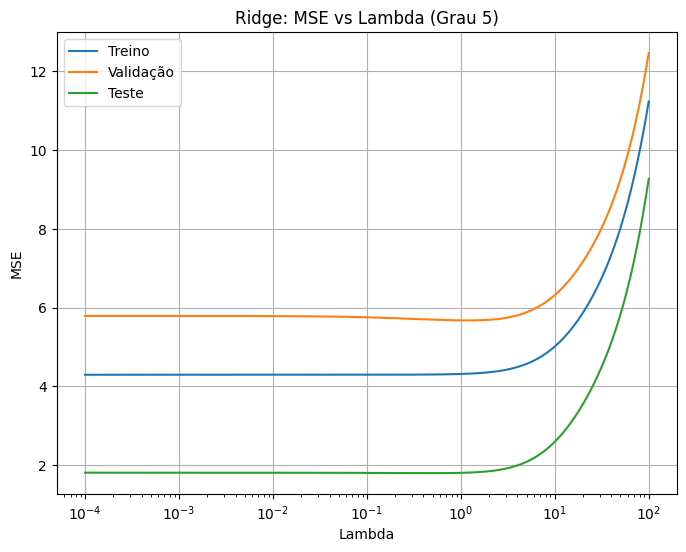

Coeficientes (linear sem regularização): [[ 0.         -5.20472031  2.57261182 -2.02137221  1.13705268  1.71589282]]
Intercepto (linear sem regularização): [8.1005554]
Coeficientes (Ridge regularizado): [ 0.         -5.15991828  2.42529518 -1.42956413  1.2633883   1.08354785]
Intercepto (Ridge): [8.1005554]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. Gerar dados sintéticos
M = 150
x = np.random.uniform(-5, 5, M).reshape(-1, 1)
epsilon = np.random.normal(0, 2, (M, 1))  # variância = 4 => desvio=2
y = 3 - 2*x + 0.5*x**2 + epsilon

# Dividir em treino (60%), val (20%), teste (20%)
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)  # 0.25*0.8=0.2

# 2. Polinômio de grau 5
degree = 5
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(x_train)
X_val_poly = poly.transform(x_val)
X_test_poly = poly.transform(x_test)

# Padronizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 3. Testar Lambdas de 1e-4 a 1e2
lambdas_ridge = np.logspace(-4, 2, 200)
train_mse_ridge = []
val_mse_ridge = []
test_mse_ridge = []
best_val_err_ridge = np.inf
best_lambda_ridge = None
best_ridge_model = None

for lam in lambdas_ridge:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    y_train_pred = ridge.predict(X_train_scaled)
    y_val_pred = ridge.predict(X_val_scaled)
    y_test_pred = ridge.predict(X_test_scaled)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    train_mse_ridge.append(mse_train)
    val_mse_ridge.append(mse_val)
    test_mse_ridge.append(mse_test)
    if mse_val < best_val_err_ridge:
        best_val_err_ridge = mse_val
        best_lambda_ridge = lam
        best_ridge_model = ridge

print(f"Melhor lambda Ridge: {best_lambda_ridge:.6f}")

# 5. Plotar MSE vs lambda
plt.figure(figsize=(8, 6))
plt.plot(lambdas_ridge, train_mse_ridge, label='Treino')
plt.plot(lambdas_ridge, val_mse_ridge, label='Validação')
plt.plot(lambdas_ridge, test_mse_ridge, label='Teste')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Ridge: MSE vs Lambda (Grau 5)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Coeficientes do modelo ótimo vs regressão sem regularização
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
print("Coeficientes (linear sem regularização):", linreg.coef_)
print("Intercepto (linear sem regularização):", linreg.intercept_)

print("Coeficientes (Ridge regularizado):", best_ridge_model.coef_)
print("Intercepto (Ridge):", best_ridge_model.intercept_)

# Discussão: A regularização tende a diminuir (em magnitude) os coeficientes em comparação com o modelo sem regularização,
#             diminuindo overfitting e melhorando a generalização.
